# Steam Game Success Prediction - Binary Classification

This notebook builds machine learning models to predict whether a Steam game is **highly rated**.

**Target variable:** `is_highly_rated`

- `1`: the game is highly rated
- `0`: the game is not highly rated

The dataset used in this notebook was prepared in BigQuery using the SQL pipeline in the `sql/` folder.


## 1. Import Libraries

The required libraries are loaded below. The notebook uses LightGBM and CatBoost because both models can work well with structured tabular data and categorical features.


In [3]:
!pip install -q lightgbm catboost optuna

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import optuna

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


## 2. Load Dataset

The modeling dataset is loaded from Google Drive. Update the path if the file is stored in a different folder.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/steam_dataset_2025/steam_ml.csv'

df = pd.read_csv(DATA_PATH)
df.head()


Mounted at /content/drive


,appid,name,type,is_free,release_date,metacritic_score,recommendations_total,mat_initial_price,mat_final_price,mat_discount_percent,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_achievement_count,total_reviews,positive_reviews,negative_reviews,positive_rate,avg_playtime_forever,avg_playtime_at_review,avg_weighted_vote_score,total_votes_up,total_votes_funny,steam_purchase_reviews,received_for_free_reviews,early_access_reviews,genres,developers,publishers,categories,release_year,price_usd,has_reviews,is_successful,price_type,platform_count,type_clean,genres_clean,developers_clean,publishers_clean,categories_clean,total_reviews_clean,positive_reviews_clean,negative_reviews_clean,recommendations_total_clean,achievement_count_clean,has_metacritic,is_highly_rated
0,1101030,Noara: The Conspiracy,game,True,2021-11-14,NaN,NaN,NaN,NaN,NaN,True,True,True,NaN,1,0,1,0.0,2808.0,2808.0,0.5000,0,0,1,0,1,"Action, Early Access, Free To Play, Indie, Str...",ATYPIQUE studio,ATYPIQUE studio,"Co-op, Multi-player, Online Co-op, Online PvP,...",2021.0,NaN,True,False,Free,3,game,"Action, Early Access, Free To Play, Indie, Str...",ATYPIQUE studio,ATYPIQUE studio,"Co-op, Multi-player, Online Co-op, Online PvP,...",1,0,1,0,0,0,0
1,231467,COH 2 - Soviet Skin: (L) Three Color Leningrad...,dlc,False,2013-06-24,NaN,NaN,199.0,61.0,69.0,True,True,True,NaN,1,0,1,0.0,0.0,143.0,0.4553,3,0,1,0,0,Strategy,"Feral Interactive (Linux), Feral Interactive (...","Feral Interactive (Linux), Feral Interactive (...","Downloadable Content, Family Sharing, Multi-pl...",2013.0,0.61,True,False,Paid,3,dlc,Strategy,"Feral Interactive (Linux), Feral Interactive (...","Feral Interactive (Linux), Feral Interactive (...","Downloadable Content, Family Sharing, Multi-pl...",1,0,1,0,0,0,0
2,3399830,The Last of them,game,False,2025-04-11,NaN,NaN,499.0,499.0,0.0,True,True,True,NaN,1,0,1,0.0,100.0,100.0,0.5000,0,0,1,0,0,"Action, Adventure, Indie",Mohammad amin,Studio,"Family Sharing, Single-player",2025.0,4.99,True,False,Paid,3,game,"Action, Adventure, Indie",Mohammad amin,Studio,"Family Sharing, Single-player",1,0,1,0,0,0,0
3,3383390,Tonya The Killer,game,False,2024-12-23,NaN,NaN,399.0,399.0,0.0,True,True,True,NaN,1,0,1,0.0,17.0,17.0,0.5217,1,0,1,0,0,"Action, Adventure, Casual, Indie",Gowi Game Studios,Gowi Game Studios,"Family Sharing, Single-player",2024.0,3.99,True,False,Paid,3,game,"Action, Adventure, Casual, Indie",Gowi Game Studios,Gowi Game Studios,"Family Sharing, Single-player",1,0,1,0,0,0,0
4,1675070,SMETANKA,game,False,2021-07-13,NaN,NaN,199.0,55.0,72.0,True,True,True,8.0,1,0,1,0.0,42.0,42.0,0.5000,0,0,1,0,0,"Action, Adventure, Casual, Indie, Massively Mu...",Diamond Cats Studio,theNeko,"Family Sharing, Single-player, Steam Achievements",2021.0,0.55,True,False,Paid,3,game,"Action, Adventure, Casual, Indie, Massively Mu...",Diamond Cats Studio,theNeko,"Family Sharing, Single-player, Steam Achievements",1,0,1,0,8,0,0


## 3. Data Overview

Before modeling, the dataset size, column structure, missing values, and target distribution are checked.


In [5]:
print("Dataset shape:", df.shape)
df.info()


Dataset shape: (117311, 48)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117311 entries, 0 to 117310
Data columns (total 48 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   appid                        117311 non-null  int64  
 1   name                         117311 non-null  object 
 2   type                         117063 non-null  object 
 3   is_free                      117311 non-null  bool   
 4   release_date                 116826 non-null  object 
 5   metacritic_score             4454 non-null    float64
 6   recommendations_total        22445 non-null   float64
 7   mat_initial_price            110378 non-null  float64
 8   mat_final_price              110378 non-null  float64
 9   mat_discount_percent         110378 non-null  float64
 10  mat_supports_windows         117311 non-null  bool   
 11  mat_supports_mac             117311 non-null  bool   
 12  mat_supports_linux           1

In [6]:
df.describe(include="all").T.head(30)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appid,117311.0,NaN,NaN,NaN,1647462.783439,985969.31469,400.0,808255.0,1517202.0,2399175.0,3977550.0
name,117311,116765,Alone,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,117063,5,game,85529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_free,117311,2,False,112699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_date,116826,5140,2020-06-18,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
metacritic_score,4454.0,NaN,NaN,NaN,73.861922,10.35737,6.0,68.0,76.0,81.0,97.0
recommendations_total,22445.0,NaN,NaN,NaN,4367.327512,34132.61626,101.0,174.0,368.0,1201.0,1835735.0
mat_initial_price,110378.0,NaN,NaN,NaN,28228.541593,976043.099446,50.0,299.0,599.0,1099.0,89900000.0
mat_final_price,110378.0,NaN,NaN,NaN,25614.137709,886595.453954,44.0,299.0,499.0,999.0,89100000.0
mat_discount_percent,110378.0,NaN,NaN,NaN,6.170577,19.086113,0.0,0.0,0.0,0.0,95.0


In [7]:
missing_values = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_values[missing_values["missing_count"] > 0].head(30)


,missing_count
metacritic_score,112857
recommendations_total,94866
mat_achievement_count,65679
mat_initial_price,6933
mat_final_price,6933
mat_discount_percent,6933
price_usd,6933
publishers,5913
genres,3226
categories,3177


In [8]:
target_counts = df["is_highly_rated"].value_counts().sort_index()
target_ratio = df["is_highly_rated"].value_counts(normalize=True).sort_index() * 100

pd.DataFrame({
    "count": target_counts,
    "percentage": target_ratio.round(2)
})


,count,percentage
is_highly_rated,,
0,54864,46.77
1,62447,53.23


## 4. Data Filtering

Very high price values were treated as extreme outliers. For the modeling dataset, games with `price_usd <= 100` are kept.


In [9]:
df_model = df.copy()
df_model = df_model[df_model["price_usd"] <= 100].copy()

print("Shape after price filtering:", df_model.shape)


Shape after price filtering: (109629, 48)


## 5. Feature Selection

Columns that directly leak review outcomes or are not useful for model training are removed. The remaining columns are used as model features.


In [10]:
TARGET = "is_highly_rated"

leakage_and_unused_cols = [
    "appid",
    "name",
    "positive_rate",
    "positive_reviews",
    "negative_reviews",
    "total_reviews",
    "is_successful",
    "has_reviews",
    "total_reviews_clean",
    "positive_reviews_clean",
    "negative_reviews_clean",
    "recommendations_total",
    "recommendations_total_clean",
    "avg_playtime_forever",
    "avg_playtime_at_review",
    "avg_weighted_vote_score",
    "total_votes_up",
    "total_votes_funny",
    "steam_purchase_reviews",
    "received_for_free_reviews",
    "early_access_reviews",
    "type",
    "release_date",
    "genres",
    "developers",
    "publishers",
    "categories",
    "mat_initial_price",
    "mat_final_price",
    "mat_discount_percent",
    "mat_achievement_count"
]

X = df_model.drop(columns=[TARGET], errors="ignore")
X = X.drop(columns=[col for col in leakage_and_unused_cols if col in X.columns], errors="ignore")
y = df_model[TARGET]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
X.head()


Feature matrix shape: (109629, 16)
Target shape: (109629,)


,is_free,metacritic_score,mat_supports_windows,mat_supports_mac,mat_supports_linux,release_year,price_usd,price_type,platform_count,type_clean,genres_clean,developers_clean,publishers_clean,categories_clean,achievement_count_clean,has_metacritic
1,False,NaN,True,True,True,2013.0,0.61,Paid,3,dlc,Strategy,"Feral Interactive (Linux), Feral Interactive (...","Feral Interactive (Linux), Feral Interactive (...","Downloadable Content, Family Sharing, Multi-pl...",0,0
2,False,NaN,True,True,True,2025.0,4.99,Paid,3,game,"Action, Adventure, Indie",Mohammad amin,Studio,"Family Sharing, Single-player",0,0
3,False,NaN,True,True,True,2024.0,3.99,Paid,3,game,"Action, Adventure, Casual, Indie",Gowi Game Studios,Gowi Game Studios,"Family Sharing, Single-player",0,0
4,False,NaN,True,True,True,2021.0,0.55,Paid,3,game,"Action, Adventure, Casual, Indie, Massively Mu...",Diamond Cats Studio,theNeko,"Family Sharing, Single-player, Steam Achievements",8,0
5,False,NaN,True,True,True,2022.0,1.99,Paid,3,game,"Casual, Indie",EroticGamesClub,EroticGamesClub,"Family Sharing, Single-player, Steam Achieveme...",3,0


In [11]:
X.dtypes.sort_values()


,0
is_free,bool
mat_supports_windows,bool
mat_supports_mac,bool
mat_supports_linux,bool
platform_count,int64
achievement_count_clean,int64
has_metacritic,int64
metacritic_score,float64
release_year,float64
price_usd,float64


## 6. Train-Test Split

The data is split into training and test sets. Stratification is used to preserve the target distribution in both sets.


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


X_train: (87703, 16)
X_test : (21926, 16)


## 7. Missing Value Handling and Categorical Preparation

Numerical missing values are filled using training-set statistics. Categorical columns are filled with `Unknown` and converted to appropriate types for tree-based models.


In [13]:
categorical_cols = [
    "is_free",
    "mat_supports_windows",
    "mat_supports_mac",
    "mat_supports_linux",
    "price_type",
    "type_clean",
    "genres_clean",
    "developers_clean",
    "publishers_clean",
    "categories_clean",
    "has_metacritic"
]

categorical_cols = [col for col in categorical_cols if col in X_train.columns]
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['is_free', 'mat_supports_windows', 'mat_supports_mac', 'mat_supports_linux', 'price_type', 'type_clean', 'genres_clean', 'developers_clean', 'publishers_clean', 'categories_clean', 'has_metacritic']
Numeric columns: ['metacritic_score', 'release_year', 'price_usd', 'platform_count', 'achievement_count_clean']


In [14]:
def prepare_for_lightgbm(X_train, X_test, categorical_cols, numeric_cols):
    X_train_prep = X_train.copy()
    X_test_prep = X_test.copy()

    for col in numeric_cols:
        median_value = X_train_prep[col].median()
        X_train_prep[col] = X_train_prep[col].fillna(median_value)
        X_test_prep[col] = X_test_prep[col].fillna(median_value)

    for col in categorical_cols:
        X_train_prep[col] = X_train_prep[col].astype("object").fillna("Unknown").astype("category")
        X_test_prep[col] = X_test_prep[col].astype("object").fillna("Unknown").astype("category")

    return X_train_prep, X_test_prep


def prepare_for_catboost(X_train, X_test, categorical_cols, numeric_cols):
    X_train_prep = X_train.copy()
    X_test_prep = X_test.copy()

    for col in numeric_cols:
        median_value = X_train_prep[col].median()
        X_train_prep[col] = X_train_prep[col].fillna(median_value)
        X_test_prep[col] = X_test_prep[col].fillna(median_value)

    for col in categorical_cols:
        X_train_prep[col] = X_train_prep[col].astype("object").fillna("Unknown").astype(str)
        X_test_prep[col] = X_test_prep[col].astype("object").fillna("Unknown").astype(str)

    return X_train_prep, X_test_prep

X_train_lgbm, X_test_lgbm = prepare_for_lightgbm(X_train, X_test, categorical_cols, numeric_cols)
X_train_cat, X_test_cat = prepare_for_catboost(X_train, X_test, categorical_cols, numeric_cols)


## 8. Statistical Check: Categorical Features and Target

Chi-square tests are used as a simple statistical check to see whether selected categorical variables are associated with the target variable.


In [16]:
def chi_square_test(data, feature, target):
    contingency_table = pd.crosstab(data[feature], data[target])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"Feature: {feature}")
    print(f"Chi-square statistic: {chi2:.2f}")
    print(f"P-value: {p_value:.3e}")
    print(f"Degrees of freedom: {dof}")

    if p_value < 0.05:
        print("Result: Statistically significant relationship with the target.\n")
    else:
        print("Result: No statistically significant relationship with the target.\n")

for feature in ["genres_clean", "categories_clean", "price_type", "type_clean"]:
    if feature in df_model.columns:
        chi_square_test(df_model, feature, TARGET)

Feature: genres_clean
Chi-square statistic: 5868.01
P-value: 0.000e+00
Degrees of freedom: 1827
Result: Statistically significant relationship with the target.

Feature: categories_clean
Chi-square statistic: 17584.14
P-value: 1.056e-291
Degrees of freedom: 11203
Result: Statistically significant relationship with the target.

Feature: price_type
Chi-square statistic: 0.00
P-value: 1.000e+00
Degrees of freedom: 0
Result: No statistically significant relationship with the target.

Feature: type_clean
Chi-square statistic: 2122.63
P-value: 0.000e+00
Degrees of freedom: 3
Result: Statistically significant relationship with the target.



## 9. Helper Function for Model Evaluation

The function below prints the main classification metrics used to compare models.


In [17]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob)
    }

    return pd.DataFrame([metrics])


# LightGBM Model


## 10. Baseline LightGBM Model

A baseline LightGBM model is trained first to establish an initial performance level.


In [18]:
lgbm_baseline = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lgbm_baseline.fit(X_train_lgbm, y_train)

lgbm_pred = lgbm_baseline.predict(X_test_lgbm)
lgbm_prob = lgbm_baseline.predict_proba(X_test_lgbm)[:, 1]

lgbm_baseline_results = evaluate_model(
    "LightGBM Baseline",
    y_test,
    lgbm_pred,
    lgbm_prob
)

lgbm_baseline_results


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 46925, number of negative: 40778
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011501 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13374
[LightGBM] [Info] Number of data points in the train set: 87703, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.535044 -> initscore=0.140408
[LightGBM] [Info] Start training from score 0.140408


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LightGBM Baseline,0.624555,0.640308,0.68059,0.659835,0.676476


In [19]:
lgbm_importance = pd.DataFrame({
    "feature": X_train_lgbm.columns,
    "importance": lgbm_baseline.feature_importances_
}).sort_values("importance", ascending=False)

lgbm_importance.head(20)


,feature,importance
10,genres_clean,3068
6,price_usd,2361
13,categories_clean,2341
12,publishers_clean,2008
5,release_year,1787
14,achievement_count_clean,1431
11,developers_clean,1372
9,type_clean,378
1,metacritic_score,209
15,has_metacritic,45


## 11. LightGBM Hyperparameter Optimization with Optuna

Optuna is used to tune the LightGBM model using ROC AUC as the optimization metric. You can reduce `N_TRIALS_LGBM` if you want a faster run.


In [20]:
N_TRIALS_LGBM = 30

def objective_lgbm(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.10, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 80),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.001, 0.10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.001, 0.10, log=True),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbose": -1
    }

    model = LGBMClassifier(**params)
    model.fit(X_train_lgbm, y_train)

    y_prob = model.predict_proba(X_test_lgbm)[:, 1]
    return roc_auc_score(y_test, y_prob)

study_lgbm = optuna.create_study(direction="maximize", study_name="LGBM_Optimization")
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS_LGBM, show_progress_bar=True)

print("Best ROC AUC:", study_lgbm.best_value)
print("Best parameters:", study_lgbm.best_params)


[I 2026-06-28 12:26:24,987] A new study created in memory with name: LGBM_Optimization


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-28 12:27:05,231] Trial 0 finished with value: 0.6770670167184452 and parameters: {'n_estimators': 987, 'learning_rate': 0.014649962518517344, 'num_leaves': 62, 'max_depth': 12, 'min_child_samples': 71, 'subsample': 0.9151173306047542, 'colsample_bytree': 0.9407566115969063, 'reg_alpha': 0.013326772333573211, 'reg_lambda': 0.005662769485644045}. Best is trial 0 with value: 0.6770670167184452.
[I 2026-06-28 12:27:10,619] Trial 1 finished with value: 0.6722108468029173 and parameters: {'n_estimators': 541, 'learning_rate': 0.024198413600010626, 'num_leaves': 44, 'max_depth': 4, 'min_child_samples': 42, 'subsample': 0.8598849024154336, 'colsample_bytree': 0.786270324030986, 'reg_alpha': 0.021856631692166312, 'reg_lambda': 0.056369537315253376}. Best is trial 0 with value: 0.6770670167184452.
[I 2026-06-28 12:27:22,354] Trial 2 finished with value: 0.677180451321137 and parameters: {'n_estimators': 409, 'learning_rate': 0.06782970899590025, 'num_leaves': 32, 'max_depth': 8, 'min_

## 12. Optimized LightGBM Model


In [21]:
best_lgbm = LGBMClassifier(
    **study_lgbm.best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

best_lgbm.fit(X_train_lgbm, y_train)

lgbm_tuned_pred = best_lgbm.predict(X_test_lgbm)
lgbm_tuned_prob = best_lgbm.predict_proba(X_test_lgbm)[:, 1]

lgbm_tuned_results = evaluate_model(
    "LightGBM Tuned",
    y_test,
    lgbm_tuned_pred,
    lgbm_tuned_prob
)

lgbm_tuned_results


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LightGBM Tuned,0.628113,0.642703,0.686642,0.663947,0.679395


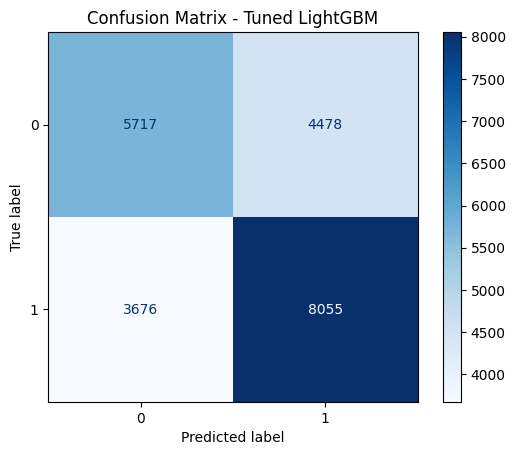

In [23]:
cm = confusion_matrix(y_test, lgbm_tuned_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_lgbm.classes_).plot(cmap='Blues')
plt.title("Confusion Matrix - Tuned LightGBM")
plt.show()

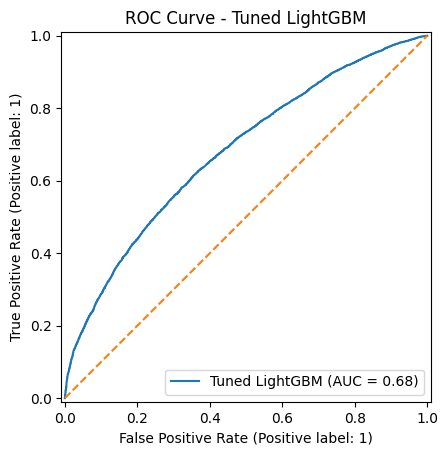

In [31]:
RocCurveDisplay.from_estimator(best_lgbm, X_test_lgbm, y_test, name="Tuned LightGBM")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Baseline")
plt.title("ROC Curve - Tuned LightGBM")
plt.show()


In [32]:
lgbm_tuned_importance = pd.DataFrame({
    "feature": X_train_lgbm.columns,
    "importance": best_lgbm.feature_importances_
}).sort_values("importance", ascending=False)

lgbm_tuned_importance.head(20)


,feature,importance
6,price_usd,9273
5,release_year,7096
10,genres_clean,6837
14,achievement_count_clean,5727
13,categories_clean,5176
12,publishers_clean,4113
11,developers_clean,3057
9,type_clean,1675
1,metacritic_score,512
15,has_metacritic,136


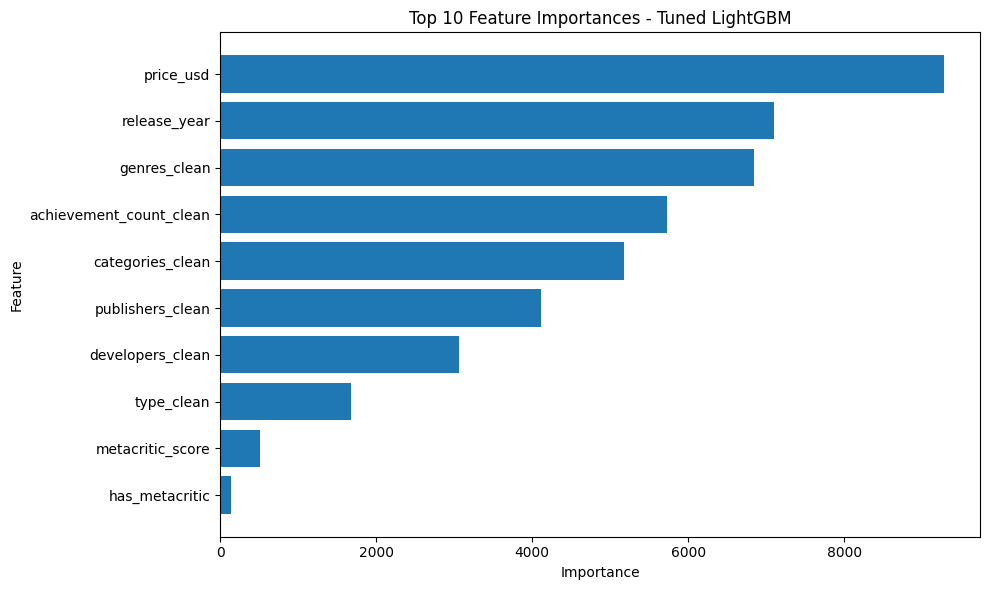

In [33]:
top_lgbm_features = lgbm_tuned_importance.head(10).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_lgbm_features["feature"], top_lgbm_features["importance"])
plt.title("Top 10 Feature Importances - Tuned LightGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# CatBoost Model


## 13. Baseline CatBoost Model

CatBoost is also tested because it handles categorical variables effectively and often performs well on tabular datasets.


In [34]:
catboost_baseline = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=100
)

catboost_baseline.fit(
    X_train_cat,
    y_train,
    eval_set=(X_test_cat, y_test),
    cat_features=categorical_cols,
    use_best_model=True
)

cat_pred = catboost_baseline.predict(X_test_cat)
cat_prob = catboost_baseline.predict_proba(X_test_cat)[:, 1]

catboost_baseline_results = evaluate_model(
    "CatBoost Baseline",
    y_test,
    cat_pred,
    cat_prob
)

catboost_baseline_results


0:	test: 0.6408321	best: 0.6408321 (0)	total: 352ms	remaining: 2m 55s
100:	test: 0.6913454	best: 0.6913454 (100)	total: 18.5s	remaining: 1m 13s
200:	test: 0.6946420	best: 0.6946420 (200)	total: 40.3s	remaining: 60s
300:	test: 0.6961397	best: 0.6961397 (300)	total: 1m	remaining: 40.2s
400:	test: 0.6965816	best: 0.6965816 (400)	total: 1m 25s	remaining: 21.1s
499:	test: 0.6966447	best: 0.6966651 (412)	total: 1m 46s	remaining: 0us

bestTest = 0.6966650988
bestIteration = 412

Shrink model to first 413 iterations.


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,CatBoost Baseline,0.639469,0.654523,0.690734,0.672141,0.696665


## 14. CatBoost Hyperparameter Optimization with Optuna

Optuna is used to tune CatBoost. You can reduce `N_TRIALS_CATBOOST` if runtime becomes too long.


In [35]:
N_TRIALS_CATBOOST = 30

def objective_catboost(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.30, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-4, 10.0, log=True),
        "random_seed": RANDOM_STATE,
        "verbose": 0,
        "eval_metric": "AUC",
        "loss_function": "Logloss",
        "early_stopping_rounds": 50
    }

    model = CatBoostClassifier(**params)
    model.fit(
        X_train_cat,
        y_train,
        eval_set=(X_test_cat, y_test),
        cat_features=categorical_cols,
        use_best_model=True,
        verbose=0
    )

    y_prob = model.predict_proba(X_test_cat)[:, 1]
    return roc_auc_score(y_test, y_prob)

study_catboost = optuna.create_study(direction="maximize", study_name="CatBoost_Optimization")
study_catboost.optimize(objective_catboost, n_trials=N_TRIALS_CATBOOST, show_progress_bar=True)

print("Best ROC AUC:", study_catboost.best_value)
print("Best parameters:", study_catboost.best_params)


[I 2026-06-28 12:44:29,778] A new study created in memory with name: CatBoost_Optimization


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-28 12:45:04,490] Trial 0 finished with value: 0.6834858106828197 and parameters: {'iterations': 279, 'learning_rate': 0.01311452465532957, 'depth': 4, 'l2_leaf_reg': 9.753973786501943}. Best is trial 0 with value: 0.6834858106828197.
[I 2026-06-28 12:45:27,310] Trial 1 finished with value: 0.693808154674078 and parameters: {'iterations': 623, 'learning_rate': 0.2766946130506029, 'depth': 6, 'l2_leaf_reg': 0.014800264405130282}. Best is trial 1 with value: 0.693808154674078.
[I 2026-06-28 12:46:06,619] Trial 2 finished with value: 0.6913991503755366 and parameters: {'iterations': 598, 'learning_rate': 0.10289614276295347, 'depth': 8, 'l2_leaf_reg': 0.000181644230574786}. Best is trial 1 with value: 0.693808154674078.
[I 2026-06-28 12:49:13,626] Trial 3 finished with value: 0.6965870369663525 and parameters: {'iterations': 873, 'learning_rate': 0.018097972096046525, 'depth': 9, 'l2_leaf_reg': 0.020534535948643844}. Best is trial 3 with value: 0.6965870369663525.
[I 2026-06-28 

## 15. Optimized CatBoost Model


In [36]:
best_catboost = CatBoostClassifier(
    **study_catboost.best_params,
    random_seed=RANDOM_STATE,
    verbose=100,
    eval_metric="AUC",
    loss_function="Logloss"
)

best_catboost.fit(
    X_train_cat,
    y_train,
    eval_set=(X_test_cat, y_test),
    cat_features=categorical_cols,
    use_best_model=True
)

cat_tuned_pred = best_catboost.predict(X_test_cat)
cat_tuned_prob = best_catboost.predict_proba(X_test_cat)[:, 1]

catboost_tuned_results = evaluate_model(
    "CatBoost Tuned",
    y_test,
    cat_tuned_pred,
    cat_tuned_prob
)

catboost_tuned_results


0:	test: 0.6432643	best: 0.6432643 (0)	total: 589ms	remaining: 9m 10s
100:	test: 0.6849034	best: 0.6849043 (99)	total: 56.6s	remaining: 7m 47s
200:	test: 0.6922003	best: 0.6922003 (200)	total: 1m 18s	remaining: 4m 46s
300:	test: 0.6943744	best: 0.6943937 (299)	total: 1m 44s	remaining: 3m 39s
400:	test: 0.6958323	best: 0.6958323 (400)	total: 2m 9s	remaining: 2m 53s
500:	test: 0.6963500	best: 0.6963589 (499)	total: 2m 33s	remaining: 2m 13s
600:	test: 0.6968962	best: 0.6968962 (600)	total: 3m 2s	remaining: 1m 41s
700:	test: 0.6972824	best: 0.6972824 (700)	total: 3m 32s	remaining: 1m 11s
800:	test: 0.6975053	best: 0.6975097 (778)	total: 4m 1s	remaining: 40.4s
900:	test: 0.6976552	best: 0.6977123 (891)	total: 4m 31s	remaining: 10.2s
934:	test: 0.6976783	best: 0.6977123 (891)	total: 4m 40s	remaining: 0us

bestTest = 0.6977122733
bestIteration = 891

Shrink model to first 892 iterations.


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,CatBoost Tuned,0.641157,0.656056,0.692183,0.673635,0.697712


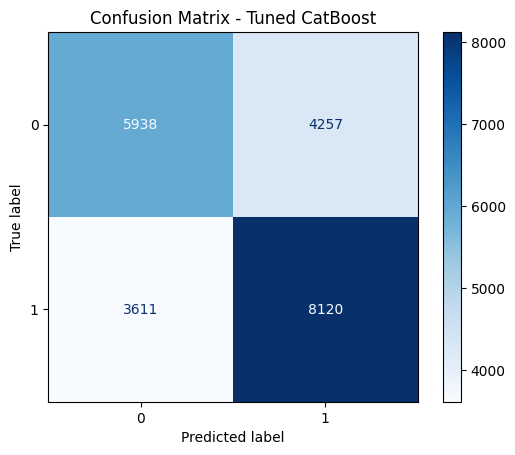

In [38]:
cm = confusion_matrix(y_test, cat_tuned_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_catboost.classes_).plot(cmap='Blues')
plt.title("Confusion Matrix - Tuned CatBoost")
plt.show()

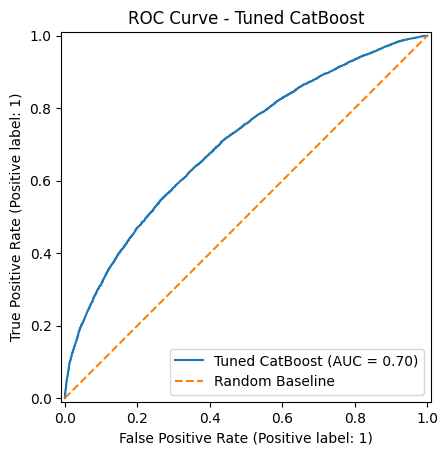

In [39]:
RocCurveDisplay.from_estimator(best_catboost, X_test_cat, y_test, name="Tuned CatBoost")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Baseline")
plt.title("ROC Curve - Tuned CatBoost")
plt.legend()
plt.show()


In [40]:
catboost_importance = pd.DataFrame({
    "feature": X_train_cat.columns,
    "importance": best_catboost.get_feature_importance()
}).sort_values("importance", ascending=False)

catboost_importance.head(20)


,feature,importance
10,genres_clean,17.512839
13,categories_clean,16.160220
12,publishers_clean,13.295047
11,developers_clean,12.628806
9,type_clean,11.798219
5,release_year,11.782760
6,price_usd,9.126141
14,achievement_count_clean,5.074516
1,metacritic_score,2.210840
15,has_metacritic,0.410610


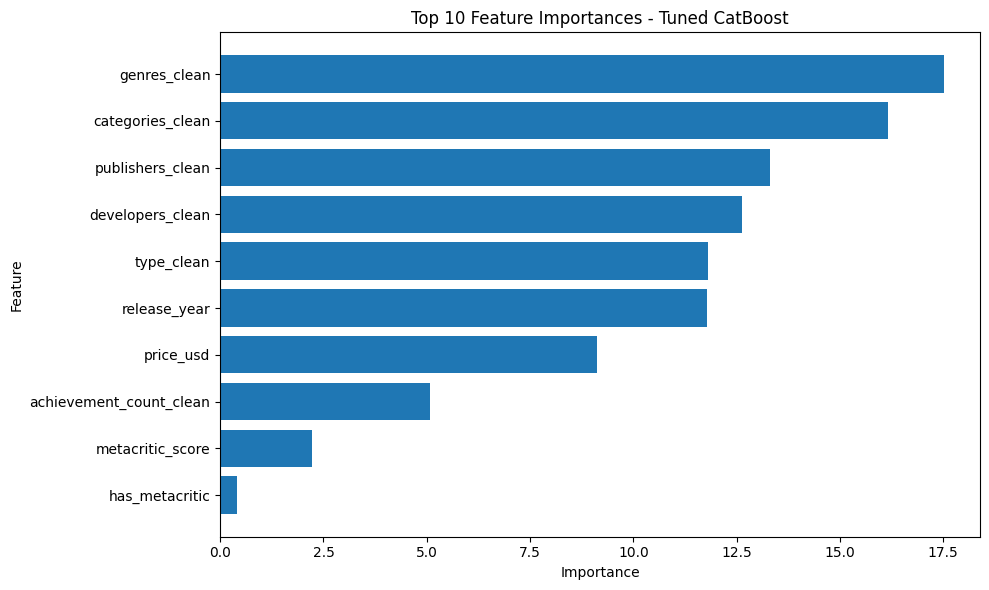

In [41]:
top_cat_features = catboost_importance.head(10).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_cat_features["feature"], top_cat_features["importance"])
plt.title("Top 10 Feature Importances - Tuned CatBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Model Comparison and Conclusion


## 16. Final Model Comparison


In [42]:
model_results = pd.concat(
    [
        lgbm_baseline_results,
        lgbm_tuned_results,
        catboost_baseline_results,
        catboost_tuned_results
    ],
    ignore_index=True
)

model_results.sort_values("ROC AUC", ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,CatBoost Tuned,0.641157,0.656056,0.692183,0.673635,0.697712
2,CatBoost Baseline,0.639469,0.654523,0.690734,0.672141,0.696665
1,LightGBM Tuned,0.628113,0.642703,0.686642,0.663947,0.679395
0,LightGBM Baseline,0.624555,0.640308,0.680590,0.659835,0.676476


## 17. Rating Distribution Check

The target is based on positive review rate, so the distribution of `positive_rate` is checked for interpretability.


In [43]:
df_model["positive_rate"].describe()


,positive_rate
count,109629.000000
mean,0.740713
std,0.348254
min,0.000000
25%,0.514300
50%,0.956500
75%,1.000000
max,1.000000


In [44]:
rating_labels = ["75-80", "81-85", "86-90", ">90"]
rating_bins = [0.75, 0.80, 0.85, 0.90, 1.00]

df_model["rating_group"] = pd.cut(
    df_model["positive_rate"],
    bins=rating_bins,
    labels=rating_labels,
    include_lowest=True
)

df_model["rating_group"].value_counts().sort_index()


,count
rating_group,
75-80,5828
81-85,2967
86-90,3989
>90,58114


## 18. Conclusion

This notebook tested LightGBM and CatBoost models for predicting highly rated Steam games. The final model should be selected primarily based on ROC AUC, while also considering precision, recall, and F1 score.

Key points to report:

- The model uses game metadata, price, platform support, genre, category, publisher, developer, and release-year features.
- Review-related leakage variables were removed from the feature set.
- CatBoost and LightGBM were compared because both are strong models for structured tabular data.
- Feature importance helps explain which variables contributed most to the predictions.

For the final project report, the best-performing model can be presented together with its ROC curve, confusion matrix, and top feature importances.
